<a href="https://colab.research.google.com/github/pandu1992/PPB_Research/blob/main/PPB_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

# ===============================
# PARAMETERS
# ===============================

T = 720                     # simulation horizon (hours)
c = 20                      # number of chargers
mu = 1/2                    # service rate (mean charging time = 2 hours)

lambda_base = 12            # baseline EV arrival rate
beta = 0.15                 # price elasticity
sigma_d = 2                 # demand noise
sigma_f = 2                 # forecast noise

p_static = 0.5
p_base = 0.6
p_max = 1.5
alpha = 0.05

np.random.seed(42)


# ===============================
# DEMAND GENERATOR
# ===============================

def generate_base_demand(t):
    daily_pattern = lambda_base + 5*np.sin(2*np.pi*t/24)
    noise = np.random.normal(0, sigma_d)
    return max(daily_pattern + noise, 0)


def forecast_demand(true_demand):
    return max(true_demand + np.random.normal(0, sigma_f), 0)


def demand_response(base_demand, price):
    lam = base_demand * np.exp(-beta * price)
    return max(lam, 0)


# ===============================
# PRICING POLICIES
# ===============================

def static_policy():
    return p_static


def reactive_policy(prev_queue):
    p = p_base + alpha * prev_queue
    return min(p, p_max)


def forecast_policy(forecast):
    p = p_base + alpha * forecast
    return min(p, p_max)


# ===============================
# SIMULATION ENVIRONMENT
# ===============================

def run_simulation(policy_type="static", queue_model="queue"):

    queue = 0
    busy_chargers = []

    revenue = 0
    total_served = 0
    total_blocked = 0
    waiting_times = []

    prev_queue = 0

    for t in range(T):

        # decrease remaining service times
        busy_chargers = [s-1 for s in busy_chargers if s-1 > 0]

        busy = len(busy_chargers)
        free = c - busy

        # demand generation
        base_d = generate_base_demand(t)
        forecast = forecast_demand(base_d)

        # pricing
        if policy_type == "static":
            price = static_policy()
        elif policy_type == "reactive":
            price = reactive_policy(prev_queue)
        elif policy_type == "forecast":
            price = forecast_policy(forecast)
        else:
            price = p_static

        # demand response
        lam = demand_response(base_d, price)
        arrivals = np.random.poisson(lam)

        served_now = 0

        for i in range(arrivals):

            if free > 0:
                service_time = np.random.exponential(1/mu)
                busy_chargers.append(service_time)
                free -= 1
                served_now += 1
                total_served += 1

            else:

                if queue_model == "blocking":
                    total_blocked += 1

                elif queue_model == "queue":
                    queue += 1
                    waiting_times.append(1)

        # serve queue if chargers free
        while queue > 0 and free > 0:

            service_time = np.random.exponential(1/mu)
            busy_chargers.append(service_time)

            queue -= 1
            free -= 1
            served_now += 1
            total_served += 1

        revenue += price * served_now

        prev_queue = queue

    avg_wait = np.mean(waiting_times) if waiting_times else 0
    utilization = np.mean([min(len(busy_chargers)/c,1)])

    return {
        "policy": policy_type,
        "queue_model": queue_model,
        "revenue": revenue,
        "served": total_served,
        "blocked": total_blocked,
        "avg_wait": avg_wait,
        "utilization": utilization
    }


# ===============================
# RUN EXPERIMENTS
# ===============================

results = []

for policy in ["static","reactive","forecast"]:
    for model in ["blocking","queue"]:

        r = run_simulation(policy, model)
        results.append(r)

df = pd.DataFrame(results)
print(df)

     policy queue_model      revenue  served  blocked  avg_wait  utilization
0    static    blocking  2703.500000    5407     2710       0.0         0.95
1    static       queue  2814.000000    5628        0       1.0         1.00
2  reactive    blocking  3240.600000    5401     2566       0.0         1.00
3  reactive       queue  8416.900000    5638        0       1.0         1.00
4  forecast    blocking  6425.459746    5274     2015       0.0         1.00
5  forecast       queue  6755.255822    5639        0       1.0         1.00


     policy queue_model  revenue_mean  revenue_std  utilization_mean
0    static    blocking   2216.333333    30.815130          0.472111
1    static       queue   2668.883333    51.750794          0.569178
2  reactive    blocking   2634.060000    34.184681          0.468106
3  reactive       queue   4369.709000   195.014282          0.541868
4  forecast    blocking   3772.377753    51.907583          0.461139
5  forecast       queue   4323.232869    67.170272          0.539065


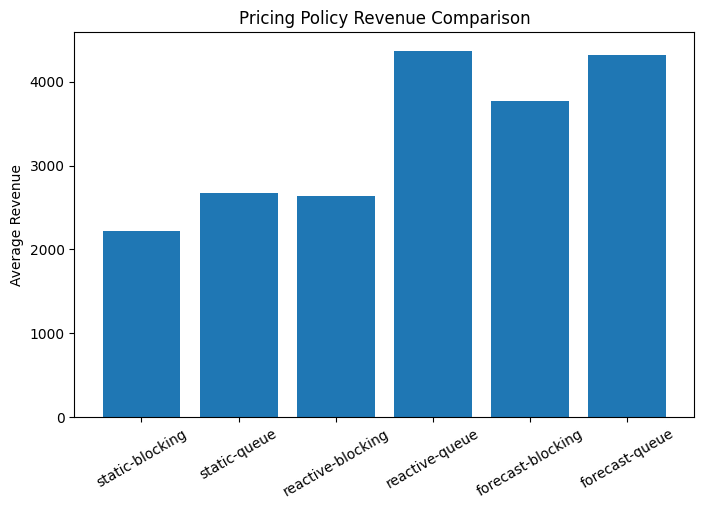

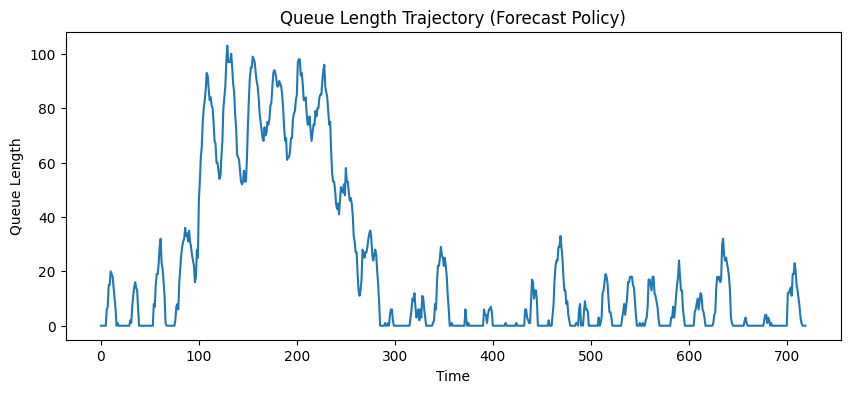

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# PARAMETERS
# ===============================

T = 720
c = 20
mu = 1/2

lambda_base = 8
beta = 0.15

sigma_d = 2
sigma_f = 2

p_static = 0.5
p_base = 0.6
p_max = 1.2
alpha = 0.03

N_SEEDS = 30


# ===============================
# DEMAND MODEL
# ===============================

def generate_base_demand(t):
    daily = lambda_base + 4*np.sin(2*np.pi*t/24)
    noise = np.random.normal(0, sigma_d)
    return max(daily + noise, 0)


def forecast_demand(d):
    return max(d + np.random.normal(0, sigma_f),0)


def demand_response(d, p):
    lam = d * np.exp(-beta*p)
    return max(lam,0)


# ===============================
# POLICIES
# ===============================

def static_policy():
    return p_static


def reactive_policy(q):
    return min(p_base + alpha*q, p_max)


def forecast_policy(f):
    return min(p_base + alpha*f, p_max)


# ===============================
# SIMULATION
# ===============================

def run_simulation(policy, queue_model):

    queue = 0
    busy = []

    revenue = 0
    served = 0
    blocked = 0

    busy_history = []
    queue_history = []

    prev_q = 0

    for t in range(T):

        # service completion
        busy = [x-1 for x in busy if x-1 > 0]

        busy_now = len(busy)
        free = c - busy_now

        busy_history.append(busy_now)
        queue_history.append(queue)

        base_d = generate_base_demand(t)
        forecast = forecast_demand(base_d)

        if policy == "static":
            price = static_policy()

        elif policy == "reactive":
            price = reactive_policy(prev_q)

        else:
            price = forecast_policy(forecast)

        lam = demand_response(base_d, price)
        arrivals = np.random.poisson(lam)

        served_now = 0

        for i in range(arrivals):

            if free > 0:

                service = np.random.exponential(1/mu)
                busy.append(service)

                free -= 1
                served += 1
                served_now += 1

            else:

                if queue_model == "blocking":
                    blocked += 1

                else:
                    queue += 1

        while queue > 0 and free > 0:

            service = np.random.exponential(1/mu)
            busy.append(service)

            queue -= 1
            free -= 1

            served += 1
            served_now += 1

        revenue += price * served_now

        prev_q = queue

    util = np.mean(busy_history)/c
    avg_q = np.mean(queue_history)

    return revenue, served, blocked, util, avg_q, queue_history


# ===============================
# MULTI-SEED EXPERIMENT
# ===============================

records = []
queue_example = None

for policy in ["static","reactive","forecast"]:
    for model in ["blocking","queue"]:

        revenues = []
        utils = []

        for seed in range(N_SEEDS):

            np.random.seed(seed)

            r,s,b,u,q,trajectory = run_simulation(policy,model)

            revenues.append(r)
            utils.append(u)

            if seed == 0 and policy=="forecast" and model=="queue":
                queue_example = trajectory

        records.append({
            "policy":policy,
            "queue_model":model,
            "revenue_mean":np.mean(revenues),
            "revenue_std":np.std(revenues),
            "utilization_mean":np.mean(utils)
        })

df = pd.DataFrame(records)
print(df)


# ===============================
# PLOT REVENUE COMPARISON
# ===============================

plt.figure(figsize=(8,5))

labels = df["policy"] + "-" + df["queue_model"]

plt.bar(labels, df["revenue_mean"])

plt.ylabel("Average Revenue")
plt.title("Pricing Policy Revenue Comparison")

plt.xticks(rotation=30)

plt.show()


# ===============================
# PLOT QUEUE TRAJECTORY
# ===============================

plt.figure(figsize=(10,4))

plt.plot(queue_example)

plt.title("Queue Length Trajectory (Forecast Policy)")
plt.xlabel("Time")
plt.ylabel("Queue Length")

plt.show()

In [5]:
# ==============================# INSTALL (if needed)# ==============================import numpy as npimport torchimport torch.nn as nnimport torch.optim as optimimport randomimport matplotlib.pyplot as plt# ==============================# ENVIRONMENT PARAMETERS# ==============================T = 720c = 20mu = 1/2lambda_base = 8beta = 0.15sigma_d = 2price_levels = np.array([0.4,0.6,0.8,1.0,1.2])# ==============================# DEMAND FUNCTIONS# ==============================def generate_base_demand(t):    daily = lambda_base + 4*np.sin(2*np.pi*t/24)    noise = np.random.normal(0,sigma_d)    return max(daily + noise,0)def demand_response(d,p):    lam = d*np.exp(-beta*p)    return max(lam,0)# ==============================# ENVIRONMENT# ==============================class EVChargingEnv:    def __init__(self):        self.reset()    def reset(self):        self.queue = 0        self.busy = []        self.t = 0        return self.get_state()    def get_state(self):        busy_now = len(self.busy)        return np.array([            self.queue/100,            busy_now/c,            (self.t%24)/24        ],dtype=np.float32)    def step(self,action):        price = price_levels[action]        # service completion        self.busy = [x-1 for x in self.busy if x-1>0]        busy_now = len(self.busy)        free = c - busy_now        base_d = generate_base_demand(self.t)        lam = demand_response(base_d,price)        arrivals = np.random.poisson(lam)        served_now = 0        for _ in range(arrivals):            if free>0:                service = np.random.exponential(1/mu)                self.busy.append(service)                free-=1                served_now+=1            else:                self.queue+=1        while self.queue>0 and free>0:            service = np.random.exponential(1/mu)            self.busy.append(service)            self.queue-=1            free-=1            served_now+=1        reward = price*served_now        self.t+=1        done = self.t>=T        return self.get_state(),reward,done,{}# ==============================# DQN NETWORK# ==============================class DQN(nn.Module):    def __init__(self,state_dim,action_dim):        super().__init__()        self.net = nn.Sequential(            nn.Linear(state_dim,64),            nn.ReLU(),            nn.Linear(64,64),            nn.ReLU(),            nn.Linear(64,action_dim)        )    def forward(self,x):        return self.net(x)# ==============================# TRAINING PARAMETERS# ==============================state_dim = 3action_dim = len(price_levels)gamma = 0.99lr = 1e-3epsilon = 1.0epsilon_decay = 0.995epsilon_min = 0.05episodes = 200model = DQN(state_dim,action_dim)optimizer = optim.Adam(model.parameters(),lr=lr)memory = []batch_size = 64# ==============================# TRAINING LOOP# ==============================env = EVChargingEnv()episode_rewards = []for ep in range(episodes):    state = env.reset()    total_reward = 0    done=False    while not done:        if np.random.rand()<epsilon:            action = np.random.randint(action_dim)        else:            with torch.no_grad():                q = model(torch.tensor(state))                action = torch.argmax(q).item()        next_state,reward,done,_ = env.step(action)        memory.append((state,action,reward,next_state,done))        state = next_state        total_reward+=reward        if len(memory)>batch_size:            batch = random.sample(memory,batch_size)            states = torch.tensor([b[0] for b in batch])            actions = torch.tensor([b[1] for b in batch])            rewards = torch.tensor([b[2] for b in batch])            next_states = torch.tensor([b[3] for b in batch])            dones = torch.tensor([b[4] for b in batch])            q_values = model(states)            q_value = q_values.gather(1,actions.unsqueeze(1)).squeeze()            with torch.no_grad():                next_q = model(next_states).max(1)[0]                target = rewards + gamma*next_q*(~dones)            loss = nn.MSELoss()(q_value,target)            optimizer.zero_grad()            loss.backward()            optimizer.step()    epsilon = max(epsilon*epsilon_decay,epsilon_min)    episode_rewards.append(total_reward)    if ep%20==0:        print(

Episode: 0 Reward: 4170.799999999997
Episode: 20 Reward: 4280.599999999999
Episode: 40 Reward: 4391.200000000002
Episode: 60 Reward: 4454.6
Episode: 80 Reward: 4490.999999999998
Episode: 100 Reward: 4418.600000000001
Episode: 120 Reward: 4715.000000000005
Episode: 140 Reward: 4790.800000000001
Episode: 160 Reward: 4829.0
Episode: 180 Reward: 4743.000000000004


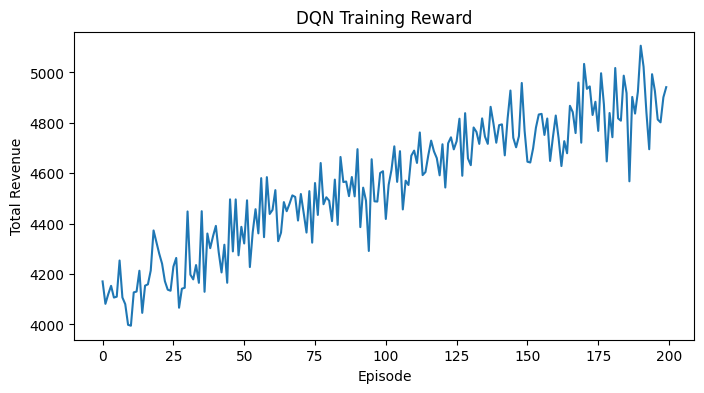

In [11]:


# ==============================
# ENVIRONMENT PARAMETERS
# ==============================

T = 720
c = 20
mu = 1/2

lambda_base = 8
beta = 0.15

sigma_d = 2

price_levels = np.array([0.4,0.6,0.8,1.0,1.2])

# ==============================
# DEMAND FUNCTIONS
# ==============================

def generate_base_demand(t):
    daily = lambda_base + 4*np.sin(2*np.pi*t/24)
    noise = np.random.normal(0,sigma_d)
    return max(daily + noise,0)

def demand_response(d,p):
    lam = d*np.exp(-beta*p)
    return max(lam,0)

# ==============================
# ENVIRONMENT
# ==============================

class EVChargingEnv:

    def __init__(self):
        self.reset()

    def reset(self):

        self.queue = 0
        self.busy = []
        self.t = 0

        return self.get_state()

    def get_state(self):

        busy_now = len(self.busy)

        return np.array([
            self.queue/100,
            busy_now/c,
            (self.t%24)/24
        ],dtype=np.float32)

    def step(self,action):

        price = price_levels[action]

        # service completion
        self.busy = [x-1 for x in self.busy if x-1>0]

        busy_now = len(self.busy)
        free = c - busy_now

        base_d = generate_base_demand(self.t)
        lam = demand_response(base_d,price)

        arrivals = np.random.poisson(lam)

        served_now = 0

        for _ in range(arrivals):

            if free>0:

                service = np.random.exponential(1/mu)
                self.busy.append(service)

                free-=1
                served_now+=1

            else:

                self.queue+=1

        while self.queue>0 and free>0:

            service = np.random.exponential(1/mu)
            self.busy.append(service)

            self.queue-=1
            free-=1
            served_now+=1

        reward = price*served_now

        self.t+=1

        done = self.t>=T

        return self.get_state(),reward,done,{}

# ==============================
# DQN NETWORK
# ==============================

class DQN(nn.Module):

    def __init__(self,state_dim,action_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(state_dim,64),
            nn.ReLU(),
            nn.Linear(64,64),
            nn.ReLU(),
            nn.Linear(64,action_dim)
        )

    def forward(self,x):
        return self.net(x)

# ==============================
# TRAINING PARAMETERS
# ==============================

state_dim = 3
action_dim = len(price_levels)

gamma = 0.99
lr = 1e-3
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.05

episodes = 200

model = DQN(state_dim,action_dim)
optimizer = optim.Adam(model.parameters(),lr=lr)

memory = []

batch_size = 64

# ==============================
# TRAINING LOOP
# ==============================

env = EVChargingEnv()

episode_rewards = []

for ep in range(episodes):

    state = env.reset()
    total_reward = 0

    done=False

    while not done:

        if np.random.rand()<epsilon:
            action = np.random.randint(action_dim)
        else:
            with torch.no_grad():
                q = model(torch.tensor(state))
                action = torch.argmax(q).item()

        next_state,reward,done,_ = env.step(action)

        memory.append((state,action,reward,next_state,done))

        state = next_state
        total_reward+=reward

        if len(memory)>batch_size:

            batch = random.sample(memory,batch_size)

            states = torch.tensor([b[0] for b in batch], dtype=torch.float32)
            actions = torch.tensor([b[1] for b in batch])
            rewards = torch.tensor([b[2] for b in batch], dtype=torch.float32)
            next_states = torch.tensor([b[3] for b in batch], dtype=torch.float32)
            dones = torch.tensor([b[4] for b in batch])

            q_values = model(states)
            q_value = q_values.gather(1,actions.unsqueeze(1)).squeeze()

            with torch.no_grad():
                next_q = model(next_states).max(1)[0]
                target = rewards + gamma*next_q*(~dones)

            loss = nn.MSELoss()(q_value,target)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    epsilon = max(epsilon*epsilon_decay,epsilon_min)

    episode_rewards.append(total_reward)

    if ep%20==0:
        print("Episode:",ep,"Reward:",total_reward)

# ==============================
# PLOT TRAINING
# ==============================

plt.figure(figsize=(8,4))
plt.plot(episode_rewards)
plt.title("DQN Training Reward")
plt.xlabel("Episode")
plt.ylabel("Total Revenue")
plt.show()

Episode: 0 Reward: 3883.4000000000037
Episode: 20 Reward: 4429.800000000002
Episode: 40 Reward: 4351.999999999997
Episode: 60 Reward: 4609.599999999995
Episode: 80 Reward: 4828.799999999995
Episode: 100 Reward: 4883.400000000003
Episode: 120 Reward: 4948.599999999999
Episode: 140 Reward: 4955.6
Episode: 160 Reward: 5053.600000000001
Episode: 180 Reward: 5029.399999999999
Episode: 200 Reward: 5243.200000000003
Episode: 220 Reward: 5260.800000000008
Episode: 240 Reward: 5316.599999999998


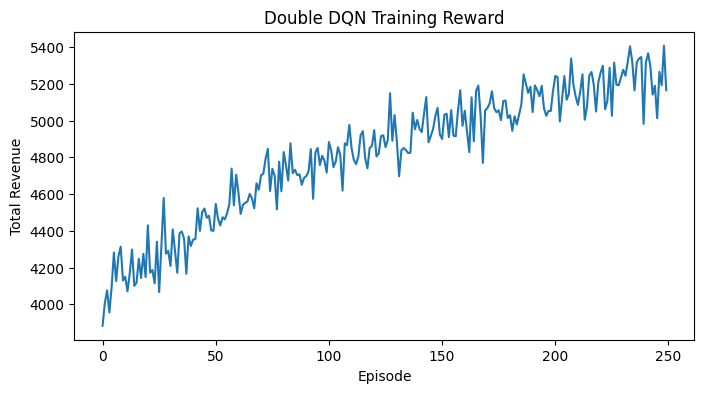

RL Mean Revenue: 5778.279999999999
RL Std Revenue: 119.61779800681863


In [14]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
import matplotlib.pyplot as plt

# =============================
# ENVIRONMENT PARAMETERS
# =============================

T = 720
c = 20
mu = 1/2

lambda_base = 8
beta = 0.15
sigma_d = 2

price_levels = np.array([0.4,0.6,0.8,1.0,1.2])

# =============================
# DEMAND MODEL
# =============================

def generate_base_demand(t):
    daily = lambda_base + 4*np.sin(2*np.pi*t/24)
    noise = np.random.normal(0,sigma_d)
    return max(daily + noise,0)

def demand_response(d,p):
    lam = d*np.exp(-beta*p)
    return max(lam,0)

# =============================
# ENVIRONMENT
# =============================

class EVChargingEnv:

    def __init__(self):
        self.reset()

    def reset(self):
        self.queue = 0
        self.busy = []
        self.t = 0
        return self.get_state()

    def get_state(self):

        busy_now = len(self.busy)

        return np.array([
            self.queue/100,
            busy_now/c,
            (self.t%24)/24
        ],dtype=np.float32)

    def step(self,action):

        price = price_levels[action]

        self.busy = [x-1 for x in self.busy if x-1>0]

        busy_now = len(self.busy)
        free = c - busy_now

        base_d = generate_base_demand(self.t)
        lam = demand_response(base_d,price)

        arrivals = np.random.poisson(lam)

        served_now = 0

        for _ in range(arrivals):

            if free>0:

                service = np.random.exponential(1/mu)
                self.busy.append(service)

                free-=1
                served_now+=1

            else:
                self.queue+=1

        while self.queue>0 and free>0:

            service = np.random.exponential(1/mu)
            self.busy.append(service)

            self.queue-=1
            free-=1
            served_now+=1

        reward = price*served_now

        self.t+=1

        done = self.t>=T

        return self.get_state(),reward,done,{}

# =============================
# DQN NETWORK
# =============================

class DQN(nn.Module):

    def __init__(self,state_dim,action_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(state_dim,128),
            nn.ReLU(),
            nn.Linear(128,128),
            nn.ReLU(),
            nn.Linear(128,action_dim)
        )

    def forward(self,x):
        return self.net(x)

# =============================
# REPLAY BUFFER
# =============================

class ReplayBuffer:

    def __init__(self,capacity=10000):
        self.buffer=[]
        self.capacity=capacity

    def push(self,transition):
        if len(self.buffer)>=self.capacity:
            self.buffer.pop(0)
        self.buffer.append(transition)

    def sample(self,batch_size):
        return random.sample(self.buffer,batch_size)

    def __len__(self):
        return len(self.buffer)

# =============================
# TRAINING PARAMETERS
# =============================

state_dim = 3
action_dim = len(price_levels)

gamma = 0.99
lr = 1e-3

epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.05

episodes = 250
batch_size = 64
target_update = 20

# =============================
# INITIALIZATION
# =============================

env = EVChargingEnv()

policy_net = DQN(state_dim,action_dim)
target_net = DQN(state_dim,action_dim)

target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.Adam(policy_net.parameters(),lr=lr)

buffer = ReplayBuffer()

episode_rewards = []

# =============================
# TRAINING LOOP
# =============================

for ep in range(episodes):

    state = env.reset()
    total_reward = 0

    done=False

    while not done:

        if np.random.rand()<epsilon:
            action = np.random.randint(action_dim)
        else:
            with torch.no_grad():
                q = policy_net(torch.tensor(state))
                action = torch.argmax(q).item()

        next_state,reward,done,_ = env.step(action)

        buffer.push((state,action,reward,next_state,done))

        state = next_state
        total_reward += reward

        if len(buffer) > batch_size:

            batch = buffer.sample(batch_size)

            states = torch.tensor([b[0] for b in batch], dtype=torch.float32)
            actions = torch.tensor([b[1] for b in batch])
            rewards = torch.tensor([b[2] for b in batch], dtype=torch.float32)
            next_states = torch.tensor([b[3] for b in batch], dtype=torch.float32)
            dones = torch.tensor([b[4] for b in batch])

            q_values = policy_net(states)
            q_value = q_values.gather(1,actions.unsqueeze(1)).squeeze()

            with torch.no_grad():

                next_actions = torch.argmax(policy_net(next_states),dim=1)

                next_q = target_net(next_states).gather(
                    1,next_actions.unsqueeze(1)).squeeze()

                target = rewards + gamma*next_q*(~dones)

            loss = nn.MSELoss()(q_value,target)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    epsilon = max(epsilon*epsilon_decay,epsilon_min)

    episode_rewards.append(total_reward)

    if ep%20==0:
        print("Episode:",ep,"Reward:",total_reward)

    if ep % target_update == 0:
        target_net.load_state_dict(policy_net.state_dict())

# =============================
# TRAINING CURVE
# =============================

plt.figure(figsize=(8,4))
plt.plot(episode_rewards)
plt.title("Double DQN Training Reward")
plt.xlabel("Episode")
plt.ylabel("Total Revenue")
plt.show()

# =============================
# EVALUATION (NO EXPLORATION)
# =============================

def evaluate_policy(env,policy_net):

    state = env.reset()
    total_reward = 0

    done=False

    while not done:

        with torch.no_grad():
            q = policy_net(torch.tensor(state))
            action = torch.argmax(q).item()

        state,reward,done,_ = env.step(action)

        total_reward+=reward

    return total_reward

eval_rewards=[]

for seed in range(20):

    np.random.seed(seed)
    eval_rewards.append(evaluate_policy(EVChargingEnv(),policy_net))

print("RL Mean Revenue:",np.mean(eval_rewards))
print("RL Std Revenue:",np.std(eval_rewards))

In [23]:
from graphviz import Digraph

dot = Digraph()

dot.node('D', 'EV Demand\n(Stochastic arrivals)')
dot.node('F', 'Demand Forecast')
dot.node('P', 'Pricing Policy\n(Rule-based / RL)')
dot.node('Q', 'Charging Station\nM/M/c Queue')
dot.node('R', 'Revenue & System Metrics')

dot.edges([
    ('D','F'),
    ('F','P'),
    ('P','Q'),
    ('Q','R')
])

dot
dot.render("EV_charging_framework", format="png")

'EV_charging_framework.png'

In [20]:
from graphviz import Digraph

dot = Digraph()

dot.node('S','State s_t\n(queue, utilization, time)')
dot.node('A','Action a_t\n(price)')
dot.node('E','Environment\nCharging Station')
dot.node('R','Reward r_t\n(revenue)')
dot.node('S2','Next State s_{t+1}')

dot.edges([
    ('S','A'),
    ('A','E'),
    ('E','R'),
    ('E','S2'),
    ('S2','A')
])

dot
dot.render("MDP_pricing_framework", format="png")

'MDP_pricing_framework.png'

In [22]:
from graphviz import Digraph

dot = Digraph()

dot.node('A','EV Arrivals\nPoisson (λ)')
dot.node('Q','Queue')
dot.node('S1','Charger 1')
dot.node('S2','Charger 2')
dot.node('Sc','Charger c')

dot.edges([
    ('A','Q'),
    ('Q','S1'),
    ('Q','S2'),
    ('Q','Sc')
])

dot
dot.render("queue_model", format="png")

'queue_model.png'

In [18]:
from graphviz import Digraph

dot = Digraph('IntegratedFramework', format='png')

dot.attr(rankdir='LR', size='10,5')

# nodes
dot.node('D', 'EV Demand\n(Stochastic arrivals)')
dot.node('F', 'Demand Forecast')
dot.node('P', 'Pricing Policy\n(Rule-based / RL)')
dot.node('MDP', 'MDP Decision Layer\n(state, action, reward)')
dot.node('Q', 'Charging Station\nM/M/c Queue')
dot.node('M', 'Performance Metrics\nRevenue, Queue, Utilization')

# edges
dot.edges([
    ('D','F'),
    ('F','P'),
    ('P','MDP'),
    ('MDP','Q'),
    ('Q','M')
])

dot
dot.render("EV_charging_framework", format="png")

'EV_charging_framework.png'